# Exploratory Data Analysis (EDA)

## Import Library & Load Data Gabungan

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# ── Setup Path ──────────────────────────────────────────────────────────────
current_dir = Path(os.getcwd())
BASE_DIR = current_dir.parent if current_dir.name == 'notebooks' else current_dir
CLEAN_PATH = BASE_DIR / 'data' / 'processed' / 'combined_clean.csv'

print(f"📁 Membaca data dari: {CLEAN_PATH}")

# ── Load Data ───────────────────────────────────────────────────────────────
df = pd.read_csv(CLEAN_PATH)
print(f"✅ Shape dataset gabungan: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()

📁 Membaca data dari: c:\G\Bootcamp\PORTOFOLIO\DermaScan\data\processed\combined_clean.csv
✅ Shape dataset gabungan: 20375 baris, 5 kolom


,image_path,dx,age,sex,localization
0,C:\G\Bootcamp\PORTOFOLIO\DermaScan\data\raw\HA...,bkl,80.0,male,scalp
1,C:\G\Bootcamp\PORTOFOLIO\DermaScan\data\raw\HA...,bkl,80.0,male,scalp
2,C:\G\Bootcamp\PORTOFOLIO\DermaScan\data\raw\HA...,bkl,80.0,male,scalp
3,C:\G\Bootcamp\PORTOFOLIO\DermaScan\data\raw\HA...,bkl,80.0,male,scalp
4,C:\G\Bootcamp\PORTOFOLIO\DermaScan\data\raw\HA...,bkl,75.0,male,ear


## Feature Engineering (Pemetaan Nama & Sumber)

In [2]:
print("⚙️ Memetakan nama kelas dan sumber dataset...")

# Kamus nama kelas gabungan (HAM10000 + SD101)
CLASS_NAMES = {
    "akiec": "Actinic Keratosis",
    "bcc"  : "Basal Cell Carcinoma",
    "bkl"  : "Benign Keratosis",
    "df"   : "Dermatofibroma",
    "mel"  : "Melanoma",
    "nv"   : "Melanocytic Nevi",
    "vasc" : "Vascular Lesion",
    "acne" : "Acne (Jerawat)",
    "dry"  : "Kulit Kering",
    "normal": "Kulit Normal",
    "oily" : "Kulit Berminyak",
    "Vitiligo": "Vitiligo"
}

# Buat kolom nama lengkap
df['dx_name'] = df['dx'].map(CLASS_NAMES).fillna(df['dx'])

# Buat kolom penanda sumber dataset
df['source'] = df['dx'].apply(
    lambda x: 'HAM10000' if x in ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'] else 'SD101'
)

print("✅ Pemetaan berhasil diterapkan!")
df[['dx', 'dx_name', 'source']].sample(5)

⚙️ Memetakan nama kelas dan sumber dataset...
✅ Pemetaan berhasil diterapkan!


,dx,dx_name,source
9129,nv,Melanocytic Nevi,HAM10000
19725,Vitiligo,Vitiligo,SD101
3561,nv,Melanocytic Nevi,HAM10000
6039,nv,Melanocytic Nevi,HAM10000
1259,mel,Melanoma,HAM10000


## Visualisasi Distribusi Keseluruhan

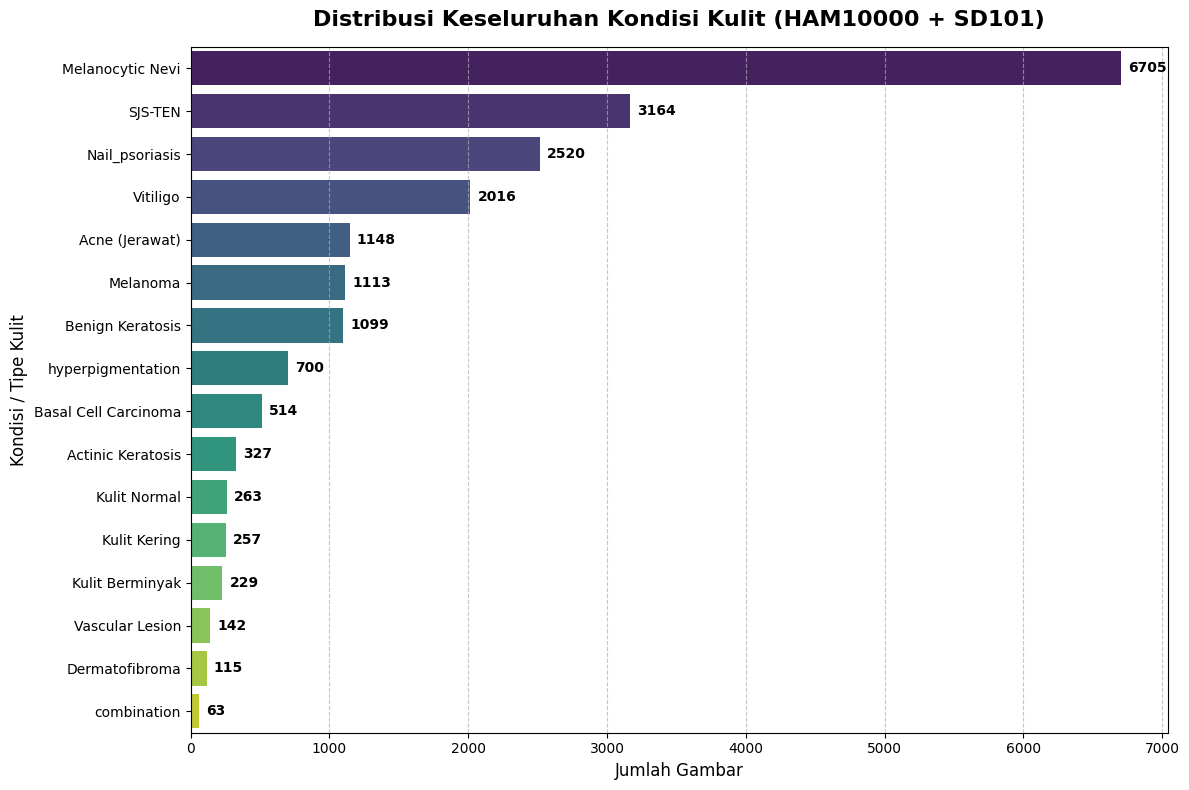

Detail Angka Distribusi per Kelas:
dx_name
Melanocytic Nevi        6705
SJS-TEN                 3164
Nail_psoriasis          2520
Vitiligo                2016
Acne (Jerawat)          1148
Melanoma                1113
Benign Keratosis        1099
hyperpigmentation        700
Basal Cell Carcinoma     514
Actinic Keratosis        327
Kulit Normal             263
Kulit Kering             257
Kulit Berminyak          229
Vascular Lesion          142
Dermatofibroma           115
combination               63
Name: count, dtype: int64


In [3]:
plt.figure(figsize=(12, 8))

# Gunakan urutan dari yang terbanyak ke terdikit
order_index = df['dx_name'].value_counts().index
sns.countplot(data=df, y='dx_name', order=order_index, palette='viridis')

plt.title('Distribusi Keseluruhan Kondisi Kulit (HAM10000 + SD101)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Jumlah Gambar', fontsize=12)
plt.ylabel('Kondisi / Tipe Kulit', fontsize=12)

# Tambahkan angka di sebelah setiap batang
for i, v in enumerate(df['dx_name'].value_counts()):
    plt.text(v + 50, i, str(v), color='black', va='center', fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Detail Angka Distribusi per Kelas:")
print(df['dx_name'].value_counts())

## Visualisasi Proporsi Sumber Data (HAM10000 vs SD101)

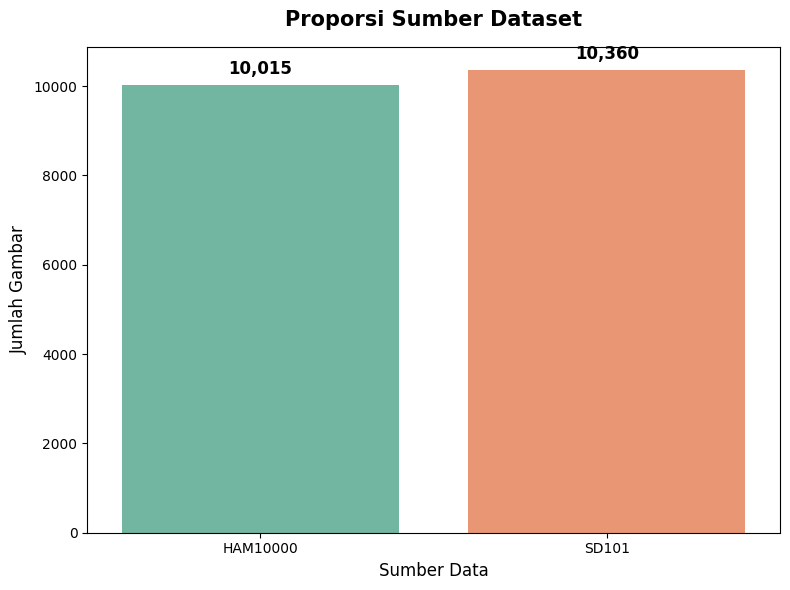

In [4]:
plt.figure(figsize=(8, 6))

ax = sns.countplot(data=df, x='source', palette='Set2')

plt.title('Proporsi Sumber Dataset', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Sumber Data', fontsize=12)
plt.ylabel('Jumlah Gambar', fontsize=12)

# Tambahkan anotasi angka di atas batang
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()